<a href="https://colab.research.google.com/github/akashgardas/Deep-Learning/blob/perceptron/models/perceptron/Perceptron_limitations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptron Limitations


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

## Activation function

In [ ]:
# activation function (step function)
def activation_function(x):
    return 1 if x >= 0 else 0

## Train Perceptron

In [ ]:
def train_perceptron(X, y, w, b, learning_rate, epochs):
  for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1}')
    for i in range(len(X)):
      z = np.dot(X[i], w) + b
      y_pred = activation_function(z)
      error = y[i] - y_pred
      w += learning_rate * error * X[i]
      b += learning_rate * error

      print(f'Data point: {X[i]}, Predicted: {y_pred}, Error: {error}, Weight: {w}, Bias: {round(b, 2)}')
  return w, b

# AND Gate

In [ ]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

X, y

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 0, 0, 1]))

In [ ]:
w = np.zeros(2)
b = 0
learning_rate = 0.1
epochs = 10

print(f'Initial Weights: {w}')
print(f'Bias: {b}')

Initial Weights: [0. 0.]
Bias: 0


In [ ]:
w, b = train_perceptron(X, y, w, b, learning_rate, epochs)


Epoch 1
Data point: [0 0], Predicted: 1, Error: -1, Weight: [0. 0.], Bias: -0.1
Data point: [0 1], Predicted: 0, Error: 0, Weight: [0. 0.], Bias: -0.1
Data point: [1 0], Predicted: 0, Error: 0, Weight: [0. 0.], Bias: -0.1
Data point: [1 1], Predicted: 0, Error: 1, Weight: [0.1 0.1], Bias: 0.0

Epoch 2
Data point: [0 0], Predicted: 1, Error: -1, Weight: [0.1 0.1], Bias: -0.1
Data point: [0 1], Predicted: 1, Error: -1, Weight: [0.1 0. ], Bias: -0.2
Data point: [1 0], Predicted: 0, Error: 0, Weight: [0.1 0. ], Bias: -0.2
Data point: [1 1], Predicted: 0, Error: 1, Weight: [0.2 0.1], Bias: -0.1

Epoch 3
Data point: [0 0], Predicted: 0, Error: 0, Weight: [0.2 0.1], Bias: -0.1
Data point: [0 1], Predicted: 1, Error: -1, Weight: [0.2 0. ], Bias: -0.2
Data point: [1 0], Predicted: 1, Error: -1, Weight: [0.1 0. ], Bias: -0.3
Data point: [1 1], Predicted: 0, Error: 1, Weight: [0.2 0.1], Bias: -0.2

Epoch 4
Data point: [0 0], Predicted: 0, Error: 0, Weight: [0.2 0.1], Bias: -0.2
Data point: [0 1]

## Final Weights

In [ ]:
print(f'Final Weights: {w}')
print(f'Final Bias: {round(b, 2)}')

Final Weights: [0.2 0.1]
Final Bias: -0.2


## Test Model

In [ ]:
print('\nTesting AND Gate')
for i in range(len(X)):
  z = np.dot(X[i], w) + b
  y_pred = activation_function(z)
  print(f'Input: {X[i]}, Prediction: {y_pred}')


Testing AND Gate
Input: [0 0], Prediction: 0
Input: [0 1], Prediction: 0
Input: [1 0], Prediction: 0
Input: [1 1], Prediction: 1


## Plots

### Decision Boundary

Text(0.5, 1.0, 'Decision Boundary for AND Gate')

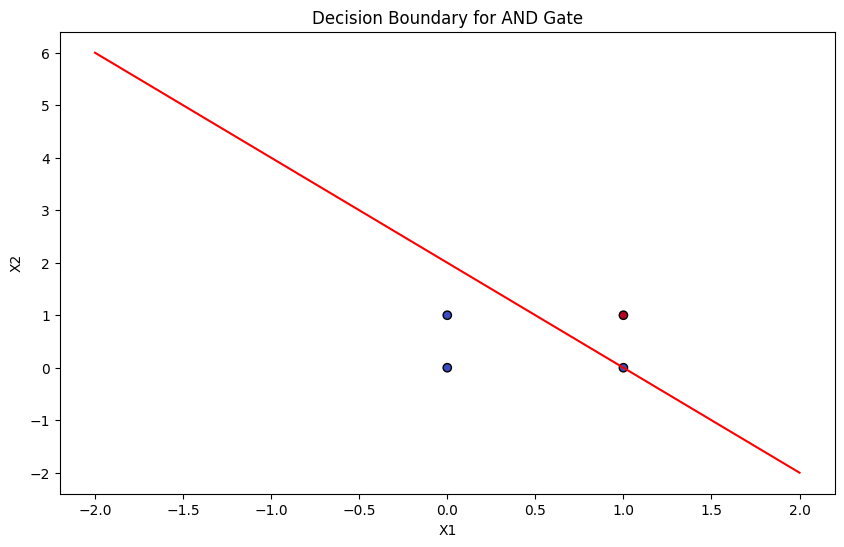

In [ ]:
# Decision Boundary - ML view
x1 = np.linspace(-2, 2, 100)
x2 = -(w[0]/w[1])*x1 - (b/w[1])

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'r-', label='Decision Boundary')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Decision Boundary for AND Gate')

### Architecture - DL view

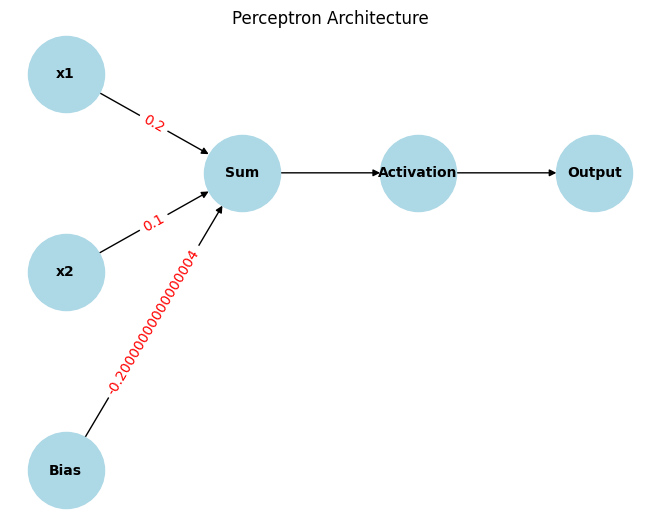

In [ ]:
G = nx.DiGraph()

# Define nodes for input layer
G.add_node('x1', pos=(0, 2), layer=0)
G.add_node('x2', pos=(0, 1), layer=0)
G.add_node('Bias', pos=(0, 0), layer=0)

# Define nodes for output layer (perceptron)
G.add_node('Sum', pos=(1, 1.5), layer=1) # Summation node
G.add_node('Activation', pos=(2, 1.5), layer=2) # Activation function node
G.add_node('Output', pos=(3, 1.5), layer=3)

# Add edges with weights
G.add_edge('x1', 'Sum', weight=w[0])
G.add_edge('x2', 'Sum', weight=w[1])
G.add_edge('Bias', 'Sum', weight=b)

G.add_edge('Sum', 'Activation')
G.add_edge('Activation', 'Output')

pos = nx.get_node_attributes(G, 'pos')

nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, font_weight='bold')

edge_labels = nx.get_edge_attributes(G, 'weight')
# Filter out None values from edge_labels if there are edges without explicit weights
filtered_edge_labels = {k: v for k, v in edge_labels.items() if v is not None}

nx.draw_networkx_edge_labels(G, pos, edge_labels=filtered_edge_labels, font_color='red')

plt.title('Perceptron Architecture')
plt.grid(True)
plt.axis('off') # Hide axes
plt.show()

# XOR Gate



In [ ]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

X, y

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 1, 1, 0]))

In [ ]:
w = np.zeros(2)
b = 0
learning_rate = 0.1
epochs = 10

print(f'Initial Weights: {w}')
print(f'Bias: {b}')

Initial Weights: [0. 0.]
Bias: 0


In [ ]:
w, b = train_perceptron(X, y, w, b, learning_rate, epochs)


Epoch 1
Data point: [0 0], Predicted: 1, Error: -1, Weight: [0. 0.], Bias: -0.1
Data point: [0 1], Predicted: 0, Error: 1, Weight: [0.  0.1], Bias: 0.0
Data point: [1 0], Predicted: 1, Error: 0, Weight: [0.  0.1], Bias: 0.0
Data point: [1 1], Predicted: 1, Error: -1, Weight: [-0.1  0. ], Bias: -0.1

Epoch 2
Data point: [0 0], Predicted: 0, Error: 0, Weight: [-0.1  0. ], Bias: -0.1
Data point: [0 1], Predicted: 0, Error: 1, Weight: [-0.1  0.1], Bias: 0.0
Data point: [1 0], Predicted: 0, Error: 1, Weight: [0.  0.1], Bias: 0.1
Data point: [1 1], Predicted: 1, Error: -1, Weight: [-0.1  0. ], Bias: 0.0

Epoch 3
Data point: [0 0], Predicted: 1, Error: -1, Weight: [-0.1  0. ], Bias: -0.1
Data point: [0 1], Predicted: 0, Error: 1, Weight: [-0.1  0.1], Bias: 0.0
Data point: [1 0], Predicted: 0, Error: 1, Weight: [0.  0.1], Bias: 0.1
Data point: [1 1], Predicted: 1, Error: -1, Weight: [-0.1  0. ], Bias: 0.0

Epoch 4
Data point: [0 0], Predicted: 1, Error: -1, Weight: [-0.1  0. ], Bias: -0.1
Dat

## Final Weigths

In [ ]:
print(f'Final Weights: {w}')
print(f'Final Bias: {round(b, 2)}')

Final Weights: [-0.1  0. ]
Final Bias: 0.0


## Train Model

In [ ]:
print('\nTesting AND Gate')
for i in range(len(X)):
  z = np.dot(X[i], w) + b
  y_pred = activation_function(z)
  print(f'Input: {X[i]}, Prediction: {y_pred}')


Testing AND Gate
Input: [0 0], Prediction: 1
Input: [0 1], Prediction: 1
Input: [1 0], Prediction: 0
Input: [1 1], Prediction: 0


## Plot

### Decision Boundary

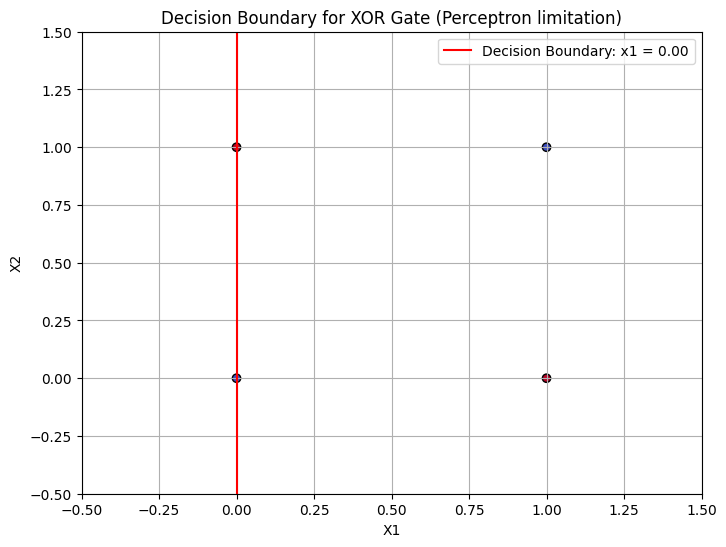

In [ ]:
plt.figure(figsize=(8, 6))

# Scatter plot of the data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')

# Plotting the decision boundary
if np.isclose(w[1], 0): # Check if w[1] is close to zero
    if np.isclose(w[0], 0):
        # Both weights are zero, no meaningful linear boundary
        plt.title('No defined linear decision boundary (weights are zero)')
    else:
        # w[1] is zero, so the boundary is a vertical line: w[0]*x1 + b = 0 => x1 = -b/w[0]
        x_intercept = -b / w[0]
        plt.axvline(x=x_intercept, color='r', linestyle='-', label=f'Decision Boundary: x1 = {x_intercept:.2f}')
        plt.title('Decision Boundary for XOR Gate (Perceptron limitation)')
else:
    # Normal case: w[1] is not zero, so the boundary is a line x2 = -(w[0]/w[1])*x1 - (b/w[1])
    x1_plot = np.linspace(-1, 2, 100)
    x2_plot = -(w[0]/w[1])*x1_plot - (b/w[1])
    plt.plot(x1_plot, x2_plot, 'r-', label='Decision Boundary')
    plt.title('Decision Boundary for XOR Gate')

plt.xlabel('X1')
plt.ylabel('X2')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.legend()
plt.grid(True)
plt.show()